<a href="https://colab.research.google.com/github/ks-chauhan/Brain-Tumor-Detection/blob/main/Early_MRI_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Dataset Download

import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [2]:
# Download Verification
import os
base_path = "/kaggle/input/brain-tumor-mri-dataset"
print(os.listdir(base_path))

['Training', 'Testing']


In [3]:
# Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

In [4]:
# Data Preprocessing

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(
    "/kaggle/input/brain-tumor-mri-dataset/Training",
    transform=transform
)

test_dataset = ImageFolder(
    "/kaggle/input/brain-tumor-mri-dataset/Testing",
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

classes = train_dataset.classes
print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
# Model Architecture

class BrainTumorCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*28*28,128),
            nn.ReLU(),
            nn.Linear(128,4)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [6]:
# Training Setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BrainTumorCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
# Model Training

epochs = 5
for epoch in range(epochs):
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss)

Epoch: 1 Loss: 128.19716718792915
Epoch: 2 Loss: 68.85960291326046
Epoch: 3 Loss: 46.16160138696432
Epoch: 4 Loss: 28.910451505333185
Epoch: 5 Loss: 17.85782149201259


In [8]:
# Model Testing

correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:",100*correct/total)

Accuracy: 86.3125


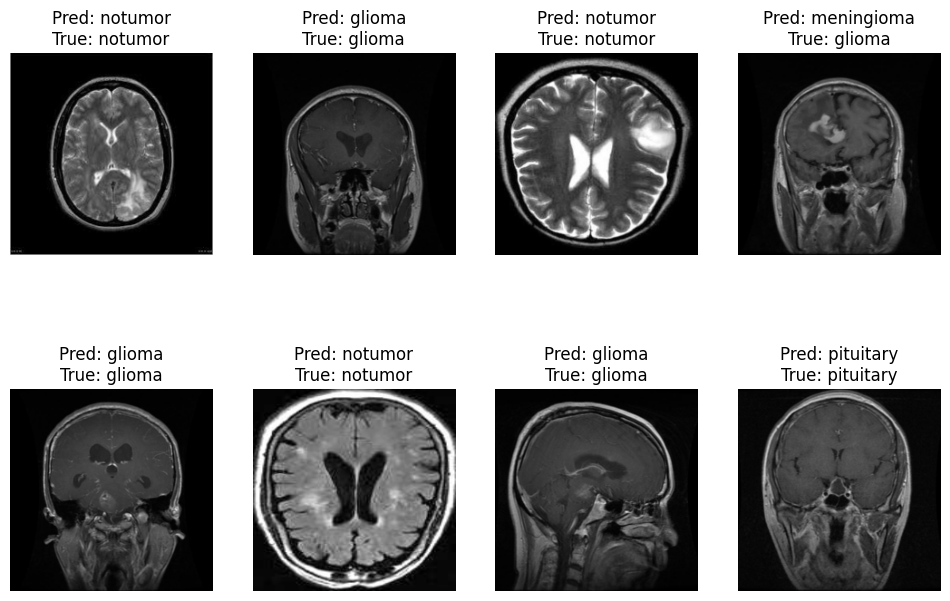

In [9]:
# Result Visualization

import matplotlib.pyplot as plt
import random
import torch

model.eval()

num_images = 8
indices = random.sample(range(len(test_dataset)), num_images)

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):

    image, label = test_dataset[idx]

    img_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output,1)

    img = image.permute(1,2,0).numpy()

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {classes[pred.item()]}\nTrue: {classes[label]}")
    plt.axis("off")

plt.show()

In [10]:
# Model Save

torch.save(model.state_dict(), "brain_tumor_cnn.pth")
print("Model saved successfully")

Model saved successfully
